## 1. What this notebook computes

This notebook is the first worked example of the chapter on the energy-momentum
tensor. It works with the commuting field dirac16complex00 (16 complex numbers at
every point) in the author's primordial metric, and it

- builds, at one chosen point of the deflating history, the coordinate gamma
  matrices, the spin connection and the energy-momentum tensor $T^\nu{}_\mu$ (an
  $8 \times 8$ table of numbers) of a field configuration chosen at random;
- checks that the tensor is real and symmetric, that its diagonal entries are
  $T^\mu{}_\mu = L_0 - K_\mu$, and computes from them the energy density $\rho$,
  the pressures $p_3$ (3-space), $p_t$ (extra times) and $p_8$ (hidden direction)
  with their kinetic and potential parts;
- checks the trace identity and the kinetic-sum identity, and what they become
  when the configuration satisfies the field equation (on shell);
- shows where the spin connection does enter the tensor (an off-diagonal entry);
- derives exactly, with sympy, the 25 Christoffel symbols of the metric and the
  covariant divergence of a diagonal tensor: the two conservation identities
  $\partial_4\rho = -3a_4'(p_3 - p_t)$ and
  $\partial_8 p_8 = -3H\cot z (2p_8 - p_3 - p_t)$;
- reads the first identity as a first law of thermodynamics for the 7-volume and
  the second one as a balance of pressures along the hidden direction;
- compares every result that the Revision record also contains with that record
  and draws five teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 09a (The energy-momentum tensor and its conservation identities) is the file
`Revision/textbook/notebooks/09a_emt_and_identities.ipynb` of the repository
Dirac_claude. It builds the energy-momentum tensor of the commuting field
dirac16complex00 at one point of the author's metric from the Revision gamma matrices and
spin connection, checks that the tensor is real and symmetric, that its diagonal entries
are the energy density and the pressures with their kinetic and potential parts, and the
trace and on-shell identities; it then derives with sympy the Christoffel symbols of the
metric and the two conservation identities of a diagonal tensor (the energy exchange
between 3-space and the extra times along x4, and the balance along the hidden direction
x8), reads the first one as a first law of thermodynamics, and draws five teaching plots.
It needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy and
matplotlib; the other packages run Jupyter, the program that shows and runs notebooks. It
does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 09a_emt_and_identities.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 09a_emt_and_identities.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
09a_emt_and_identities.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/09a.captions.json`
- `Revision/textbook/figures/09a_1_kinetic_weights.png`
- `Revision/textbook/figures/09a_2_tensor_heat_map.png`
- `Revision/textbook/figures/09a_3_diagonal_parts.png`
- `Revision/textbook/figures/09a_4_volumes_first_law.png`
- `Revision/textbook/figures/09a_5_hidden_balance.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the five figures of this notebook are saved and captioned
    ALL 27 CHECKS PASSED (notebook 09a)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/09a_emt_and_identities.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 09a_emt_and_identities.ipynb
      python -m nbconvert --execute --inplace 09a_emt_and_identities.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "KeyError" with the words "has no check": the notebook asks a Revision report for the
  verdict of one of its checks, and the report in your copy of the repository does not
  contain that check: your copy is older or newer than the notebook. Run `git pull` in
  the repository folder, then run the notebook again.
- The cell of the Christoffel symbols runs for more than a minute: sympy simplifies 288
  expressions there; on a slow computer this takes longer; wait until the cell has
  finished (its number appears in the margin) before you run the next cell.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 09a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 09a (The energy-momentum tensor and its conservation identities) is the file
# Revision/textbook/notebooks/09a_emt_and_identities.ipynb of the repository
# Dirac_claude. It builds the energy-momentum tensor of the commuting field
# dirac16complex00 at one point of the author's metric from the Revision gamma matrices
# and spin connection, checks that the tensor is real and symmetric, that its diagonal
# entries are the energy density and the pressures with their kinetic and potential
# parts, and the trace and on-shell identities; it then derives with sympy the
# Christoffel symbols of the metric and the two conservation identities of a diagonal
# tensor (the energy exchange between 3-space and the extra times along x4, and the
# balance along the hidden direction x8), reads the first one as a first law of
# thermodynamics, and draws five teaching plots. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 09a_emt_and_identities.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 09a_emt_and_identities.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 09a_emt_and_identities.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/09a.captions.json
# - Revision/textbook/figures/09a_1_kinetic_weights.png
# - Revision/textbook/figures/09a_2_tensor_heat_map.png
# - Revision/textbook/figures/09a_3_diagonal_parts.png
# - Revision/textbook/figures/09a_4_volumes_first_law.png
# - Revision/textbook/figures/09a_5_hidden_balance.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the five figures of this notebook are saved and captioned
#     ALL 27 CHECKS PASSED (notebook 09a)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/09a_emt_and_identities.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 09a_emt_and_identities.ipynb
#     python -m nbconvert --execute --inplace 09a_emt_and_identities.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "KeyError" with the words "has no check": the notebook asks a Revision report for the
#   verdict of one of its checks, and the report in your copy of the repository does not
#   contain that check: your copy is older or newer than the notebook. Run git pull in
#   the repository folder, then run the notebook again.
# - The cell of the Christoffel symbols runs for more than a minute: sympy simplifies 288
#   expressions there; on a slow computer this takes longer; wait until the cell has
#   finished (its number appears in the margin) before you run the next cell.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "09a"  # this notebook: chapter 09, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 09a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates**: $x_1, x_2, x_3$ are ordinary 3-space; $x_4$ is the time;
  $x_5, x_6, x_7$ are the three extra times; $x_8$ is the hidden space direction.
  In the code, index 0 means $x_1$, index 3 means $x_4$ and index 7 means $x_8$.
- **Tensor** $T^\nu{}_\mu$: a table of $8 \times 8$ numbers at every point, one
  for each pair of directions $(\nu, \mu)$. The upper index $\nu$ is the row, the
  lower index $\mu$ the column. Lowering the upper index with the metric gives
  $T_{\nu\mu} = g_{\nu\nu} T^\nu{}_\mu$ (the metric here is diagonal).
- **Energy-momentum tensor**: the tensor that says how much energy and momentum
  the field has and how they flow. Its diagonal entries are the energy density
  and the pressures; its off-diagonal entries are flows of energy and momentum.
- **Energy density** $\rho = -T^{x_4}{}_{x_4}$: energy per unit (proper) volume.
  **Pressure** in direction $\mu$: $p_\mu = T^\mu{}_\mu$ (no sum).
  **Equation of state**: the ratio $w = p/\rho$.
- **Kinetic term** $K_\mu$: the part of the Lagrangian that holds the derivative
  along the direction $\mu$; **potential energy**: $mS + U(S)$, the part without
  derivatives.
- **Trace**: the sum of the diagonal entries, $T^\mu{}_\mu$ summed over $\mu$.
- **Jet at a point**: the values of the field and of its eight first derivatives
  at one point. The energy-momentum tensor needs nothing else.
- **On shell / off shell**: a configuration is on shell when it satisfies the
  field equation, off shell when it need not.
- **Spin connection** $\Omega_\mu$: the $16 \times 16$ matrix that turns the
  ordinary derivative of the spinor into the covariant one,
  $D_\mu\Phi = \partial_\mu\Phi + \Omega_\mu\Phi$.
- **Christoffel symbols** $\Gamma^\lambda{}_{\mu\nu}$: the numbers that turn
  ordinary derivatives of tensors into covariant ones.
- **Covariant divergence** $\nabla_\mu T^\mu{}_\nu$: the derivative of the
  tensor summed over its upper index, corrected by the Christoffel symbols.
  **Conservation** means $\nabla_\mu T^\mu{}_\nu = 0$.
- **Heat map**: a picture of a table of numbers in which each entry is a coloured
  square; the colour scale says which number each colour means.

## 4. The physical and mathematical situation

**The metric.** The author's primordial metric is diagonal,
$g = \mathrm{diag}(f_1^2, f_2^2, f_3^2, -f_4^2, -f_5^2, -f_6^2, -f_7^2, f_8^2)$,
with the vielbein factors
$f_1 = f_2 = f_3 = e^{a_4}\sin^{1/6}z$ (3-space, inflating as $a_4$ grows),
$f_4 = 1$ (the time), $f_5 = f_6 = f_7 = e^{-a_4}\sin^{1/6}z$ (the extra times,
deflating exponentially), $f_8 = \cot z$, where $z = 6Hx_8$ lies between $0$ and
$\pi/2$, $H > 0$ is the author's constant and $a_4$ depends on $x_4$. The volume
factor is $\sqrt{|g|} = f_1 f_2 \cdots f_8 = \cos z$: it does not depend on $x_4$.
The Kohn-Sham part of the book uses the deflating history $a_4 = AHx_4$ with
$A > 0$ as a prescribed background; this notebook takes its point on that
history.

**The field and its Lagrangian.** dirac16complex00 is a column $\Phi$ of 16
complex numbers at every point. With $\bar\Phi = \Phi^\dagger C$, $S = \bar\Phi\Phi$
and $U(S) = \frac{\lambda}{2}S^2$, the Lagrangian per unit volume is
$L_0 = \frac12\sum_\mu(\bar\Phi\gamma^\mu D_\mu\Phi
- (D_\mu\bar\Phi)\gamma^\mu\Phi) - mS - U(S)$, with the coordinate gammas
$\gamma^\mu = \gamma^{(\mu)}/f_\mu$,
$D_\mu\Phi = \partial_\mu\Phi + \Omega_\mu\Phi$ and
$D_\mu\bar\Phi = \partial_\mu\bar\Phi - \bar\Phi\Omega_\mu$.

**The energy-momentum tensor** (Revision record, `Revision/theory/field-theory.json`,
formula `T_symmetric`):
$T^\nu{}_\mu = \delta^\nu_\mu L_0 - \frac14(\bar\Phi\gamma^\nu D_\mu\Phi
- D_\mu\bar\Phi \gamma^\nu\Phi + \bar\Phi\gamma_\mu D^\nu\Phi
- D^\nu\bar\Phi \gamma_\mu\Phi)$, with $\gamma_\mu = g_{\mu\mu}\gamma^\mu$ and
$D^\nu = g^{\nu\nu}D_\nu$. The sign convention is $\rho = -T^{x_4}{}_{x_4}$ and
$p_\mu = T^\mu{}_\mu$ (no sum) for $\mu \neq x_4$. This symmetric (Belinfante)
tensor is the symmetric part of the tensor that a variation of the vielbein
gives (record formula `T_variation`, which has an extra spin-density term); the
two are equal on every solution of the field equation, and for other
configurations they agree in general only on the diagonal (record check
`commuting_emt_equals_general_vielbein_variation_on_shell`). This notebook uses
the symmetric tensor `T_symmetric`; so the lowered table $T_{\nu\mu}$ computed
below for random values, which do not solve the field equation, is symmetric by
construction.

**The diagonal entries.** With the kinetic term of direction $\mu$,
$K_\mu = \frac{1}{2f_\mu}(\bar\Phi\gamma^{(\mu)}\partial_\mu\Phi
- \partial_\mu\bar\Phi \gamma^{(\mu)}\Phi)$, the record states
$L_0 = \sum_\mu K_\mu - mS - U$ and $T^\mu{}_\mu = L_0 - K_\mu$, so
$\rho = -\sum_{\mu \neq x_4}K_\mu + mS + U$ and
$p_\mu = \sum_{\nu \neq \mu}K_\nu - mS - U$.

**Conservation.** On shell $\nabla_\mu T^\mu{}_\nu = 0$ (a theorem of the record,
proved from the invariance of the action under changes of coordinates). For a
diagonal tensor $\mathrm{diag}(p_3, p_3, p_3, -\rho, p_t, p_t, p_t, p_8)$ whose
entries depend on $x_4$ and $x_8$, this notebook derives the two conditions it
becomes.

**Both fields.** The same formulas hold for the anticommuting field
dirac16complex, whose bilinears are even elements of a Grassmann algebra (the
record verifies them in its checks ending in `_G`). After quantisation the record
defines the tensor as a normal-ordered operator; the positive space of quantum
states this needs is constructed only for single good-sector momenta (waves that
do not depend on the extra times) with frozen coefficients, and for
$\lambda \neq 0$ the operator form of the on-shell identity
$\sum_\mu\langle{:}K_\mu{:}\rangle = \langle{:}(m + U')S{:}\rangle$ is verified
only in a finite model of one such mode set, and there only when the potential
and the tensor are Wick (normal) ordered as whole products
(`Revision/theory/fock_quartic/reports/fock-quartic.json`, 21 of 21 checks); for
the field on a whole slice it is OPEN. This notebook computes with ordinary
complex numbers, that is, for dirac16complex00.

## 5. The gamma matrices and the matrix C

The next cell reads the Revision fixture `Revision/algebra/gammas.json`, which
holds the author's real $16 \times 16$ gamma matrices in the order
$x_1, \dots, x_8$, the frame metric $\eta$ and the matrix
$C = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$. It also defines the
helper `recorded(path, name)`, which opens a Revision report and returns the
verdict of one of its checks; every check of this notebook that reproduces a
Revision check asks the report for that verdict too.

In [2]:
import numpy as np  # arrays of numbers, matrices, linear algebra

fixture = json.loads(
    repository_file("Revision/algebra/gammas.json").read_text(encoding="utf-8"))
# gamma[a] is the frame matrix gamma^(x_(a+1)): gamma[0] = x1, ..., gamma[7] = x8.
gamma = [np.array(rows, dtype=float) for rows in fixture["gamma"]]
eta = np.array(fixture["eta"], dtype=float)  # (+1, +1, +1, -1, -1, -1, -1, +1)
C = np.array(fixture["C"], dtype=float)  # gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3)
I16 = np.eye(16)  # the 16 x 16 unit matrix
NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]  # the author's coordinates


def recorded(path, name):
    """The verdict (PASS or FAIL) of the check name in the Revision report path."""
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for item in report_data["checks"]:
        if item["name"] == name:
            return item["verdict"].upper()  # some reports write "pass"
    raise KeyError(f"{path} has no check {name}")


ALGEBRA = "Revision/algebra/reports/python-algebra.json"
# {gamma^a, gamma^b} = gamma^a gamma^b + gamma^b gamma^a must be 2 eta^ab times 1.
clifford = all(np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                              2 * eta[a] * (a == b) * I16)
               for a in range(8) for b in range(8))
check(clifford and recorded(ALGEBRA, "clifford_relation") == "PASS",
      "the 64 Clifford relations {gamma^a, gamma^b} = 2 eta^ab",
      record=f"{ALGEBRA}, check clifford_relation")
# C is symmetric, C times C is 1, and every C gamma^a is antisymmetric.
c_ok = np.array_equal(C, C.T) and np.array_equal(C @ C, I16) and all(
    np.array_equal((C @ g).T, -(C @ g)) for g in gamma)
check(c_ok and recorded(ALGEBRA, "C_real_symmetric_involution") == "PASS"
      and recorded(ALGEBRA, "C_gamma_antisymmetric") == "PASS",
      "C is real symmetric, C^2 = 1, every C gamma^a is antisymmetric",
      record=f"{ALGEBRA}, checks C_real_symmetric_involution and "
             "C_gamma_antisymmetric")

PASS the 64 Clifford relations {gamma^a, gamma^b} = 2 eta^ab
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation
PASS C is real symmetric, C^2 = 1, every C gamma^a is antisymmetric
     reproduces Revision/algebra/reports/python-algebra.json, checks
    C_real_symmetric_involution and C_gamma_antisymmetric


## 6. The author's metric at one point and the weights of the kinetic terms

The next cell fixes the point at which the tensor is built. The author's
constant is $H = 0.25$ (all quantities are pure numbers: lengths in a unit of
our choice, $H$, $m$ and $\lambda$ in the matching powers of it). The history is
the deflating member $a_4 = AHx_4$ with $A = 1$, so $a_4' = AH = 0.25$; the point
is $x_4 = 2$ (hence $a_4 = 0.5$) and $z = \pi/4$. The function `frame_factors`
returns the eight factors $f_a$; the cell checks that $\eta_{aa}f_a^2$ is the
author's metric and that $f_1 f_2 \cdots f_8 = \cos z$.

In the energy-momentum tensor every derivative along $x_\mu$ carries the weight
$1/f_\mu$: $e^{-a_4}\sin^{-1/6}z$ along 3-space, $1$ along the time,
$e^{a_4}\sin^{-1/6}z$ along the extra times and $\tan z$ along the hidden
direction. The figure shows these weights against $a_4$ and against $z$.

In [3]:
H = 0.25  # the author's constant H
A = 1.0  # the history a4 = A H x4; A > 0: the extra times deflate
m = 1.0  # the mass m of the field
lam = 0.5  # the strength lambda of the potential U(S) = (lambda/2) S^2
X4 = 2.0  # the time x4 of the point
a4 = A * H * X4  # a4 at the point: 0.5
a4p = A * H  # its derivative da4/dx4 (written a4p, "a4 prime"): 0.25
z = np.pi / 4  # z = 6 H x8 at the point


def frame_factors(a4_value, z_value):
    """The eight factors f_a of the diagonal vielbein, in the order x1, ..., x8."""
    space = np.exp(a4_value) * np.sin(z_value) ** (1 / 6)  # e^a4 sin^(1/6) z
    extra = np.exp(-a4_value) * np.sin(z_value) ** (1 / 6)  # e^(-a4) sin^(1/6) z
    return np.array([space] * 3 + [1.0] + [extra] * 3 + [1 / np.tan(z_value)])


f = frame_factors(a4, z)
g_diag = eta * f ** 2  # the diagonal entries g_mumu = eta_mumu f_mu^2
# The author's metric written out: e^(2 a4) sin^(1/3) z, -1, -e^(-2 a4) sin^(1/3) z,
# cot^2 z.
authors = np.array([np.exp(2 * a4) * np.sin(z) ** (1 / 3)] * 3 + [-1.0]
                   + [-np.exp(-2 * a4) * np.sin(z) ** (1 / 3)] * 3
                   + [1 / np.tan(z) ** 2])
THEORY_PY = "Revision/theory/reports/python-field-theory.json"
check(np.allclose(g_diag, authors, rtol=1e-14, atol=0)
      and recorded(THEORY_PY, "metric_from_vielbein_equals_SPEC") == "PASS",
      "eta_aa f_a^2 is the author's metric at the point",
      record=f"{THEORY_PY}, check metric_from_vielbein_equals_SPEC")
check(abs(np.prod(f) - np.cos(z)) < 1e-14
      and recorded(THEORY_PY, "sqrt_det_g_equals_cos_z") == "PASS",
      "the volume factor f1 f2 ... f8 equals cos z",
      record=f"{THEORY_PY}, check sqrt_det_g_equals_cos_z")
for name, value in zip(NAMES, f):
    report(f"f_{name}", f"{value:.6f}")

PASS eta_aa f_a^2 is the author's metric at the point
     reproduces Revision/theory/reports/python-field-theory.json, check
    metric_from_vielbein_equals_SPEC
PASS the volume factor f1 f2 ... f8 equals cos z
     reproduces Revision/theory/reports/python-field-theory.json, check
    sqrt_det_g_equals_cos_z
RESULT f_x1 = 1.556186
RESULT f_x2 = 1.556186
RESULT f_x3 = 1.556186
RESULT f_x4 = 1.000000
RESULT f_x5 = 0.572489
RESULT f_x6 = 0.572489
RESULT f_x7 = 0.572489
RESULT f_x8 = 1.000000


The next cell draws the weights $1/f_\mu$. Left: against $a_4$ from $-2$ to $2$
at $z = \pi/4$; the 3-space weight falls like $e^{-a_4}$ and the extra-time
weight rises like $e^{a_4}$, so as the extra times deflate their derivatives
count more and more (the time weight and the hidden weight are both 1 there, so
their two lines coincide). Right: against $z$ at $a_4 = 0.5$; the
hidden-direction weight $\tan z$ grows without bound as $z$ approaches $\pi/2$.

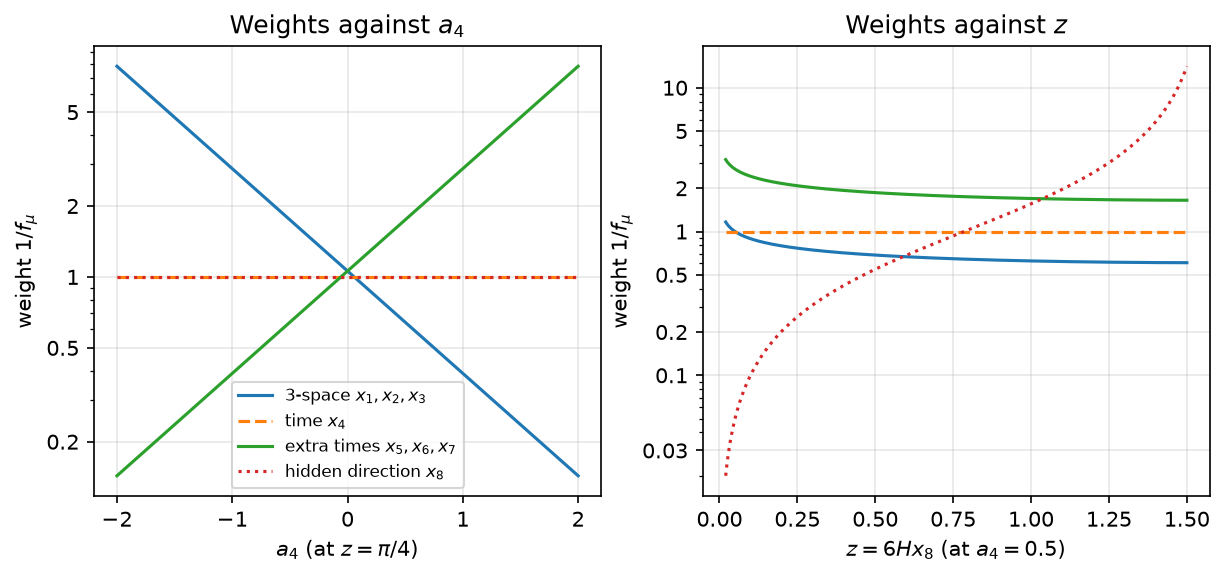

Figure 09a.1 saved as Revision/textbook/figures/09a_1_kinetic_weights.png


In [4]:
from matplotlib.ticker import NullFormatter  # a tick label that prints nothing

a4_axis = np.linspace(-2.0, 2.0, 401)  # values of a4 for the left panel
z_axis = np.linspace(0.02, 1.50, 400)  # values of z for the right panel
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.9))
weights_a4 = np.array([1 / frame_factors(value, z) for value in a4_axis])
weights_z = np.array([1 / frame_factors(a4, value) for value in z_axis])
for panel, axis, weights in ((left, a4_axis, weights_a4), (right, z_axis, weights_z)):
    panel.plot(axis, weights[:, 0], label="3-space $x_1, x_2, x_3$")
    panel.plot(axis, weights[:, 3], "--", label="time $x_4$")
    panel.plot(axis, weights[:, 4], label="extra times $x_5, x_6, x_7$")
    panel.plot(axis, weights[:, 7], ":", label="hidden direction $x_8$")
    panel.set_yscale("log")  # equal factors are equal distances on this axis
    panel.yaxis.set_minor_formatter(NullFormatter())  # no labels on minor ticks
    panel.set_ylabel("weight $1/f_\\mu$")
ticks = [0.03, 0.1, 0.2, 0.5, 1, 2, 5, 10]  # plain numbers on the vertical axes
left.set_yticks(ticks[2:7], [str(t) for t in ticks[2:7]])
right.set_yticks(ticks, [str(t) for t in ticks])
left.set_xlabel("$a_4$ (at $z = \\pi/4$)")
right.set_xlabel("$z = 6 H x_8$ (at $a_4 = 0.5$)")
left.set_title("Weights against $a_4$")
right.set_title("Weights against $z$")
left.legend(fontsize=8)
save_figure(fig, "kinetic_weights",
            "The weights $1/f_\\mu$ with which a derivative along each direction "
            "enters the energy-momentum tensor, on a logarithmic vertical axis "
            "(pure numbers). Left: against $a_4$ from $-2$ to $2$ at $z = \\pi/4$; "
            "the 3-space weight $e^{-a_4}\\sin^{-1/6}z$ falls and the extra-time "
            "weight $e^{a_4}\\sin^{-1/6}z$ rises, so derivatives along the "
            "deflating extra times count more as $a_4$ grows; the time weight is "
            "$1$ and the hidden weight is $\\tan z = 1$, so these two lines lie on "
            "top of each other. Right: against $z$ at "
            "$a_4 = 0.5$; the hidden weight $\\tan z$ grows without bound near "
            "$z = \\pi/2$.")

## 7. The spin connection at the point

The record gives the spin connection of the diagonal vielbein in closed form
(`Revision/theory/field-theory.json`, formula `Omega_components`):
$\Omega_{x_i} = \frac12 e^{a_4}\sin^{1/6}z (a_4'\gamma^{(i)}\gamma^{(4)}
+ H\gamma^{(i)}\gamma^{(8)})$ for $i = 1, 2, 3$,
$\Omega_{x_t} = -\frac12 e^{-a_4}\sin^{1/6}z (a_4'\gamma^{(4)}\gamma^{(t)}
+ H\gamma^{(t)}\gamma^{(8)})$ for $t = 5, 6, 7$, and
$\Omega_{x_4} = \Omega_{x_8} = 0$. The next cell builds these eight matrices and
the coordinate gammas $\gamma^\mu = \gamma^{(\mu)}/f_\mu$, and confirms two exact
facts of the record at this point: for each direction separately
$\gamma^\mu\Omega_\mu + \Omega_\mu\gamma^\mu = 0$ (no sum), which is why no spin
connection survives in the diagonal entries of the tensor; and summed over the
directions $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$, the term of the field
equation.

In [5]:
def spin_connection(a4_value, a4p_value, z_value):
    """The eight 16 x 16 matrices Omega_mu of the record's formula Omega_components."""
    s = np.sin(z_value) ** (1 / 6)  # sin^(1/6) z
    omega = [np.zeros((16, 16)) for _ in range(8)]  # Omega_x4 = Omega_x8 = 0
    for i in range(3):  # the three 3-space directions x1, x2, x3
        omega[i] = 0.5 * np.exp(a4_value) * s * (
            a4p_value * gamma[i] @ gamma[3] + H * gamma[i] @ gamma[7])
    for t in range(4, 7):  # the three extra times x5, x6, x7
        omega[t] = -0.5 * np.exp(-a4_value) * s * (
            a4p_value * gamma[3] @ gamma[t] + H * gamma[t] @ gamma[7])
    return omega


Omega = spin_connection(a4, a4p, z)
gamma_up = [gamma[mu] / f[mu] for mu in range(8)]  # coordinate gammas gamma^mu
gamma_down = [g_diag[mu] * gamma_up[mu] for mu in range(8)]  # gamma_mu
# {gamma^mu, Omega_mu} for each mu separately: the largest entry of all eight.
anti = max(np.abs(gamma_up[mu] @ Omega[mu] + Omega[mu] @ gamma_up[mu]).max()
           for mu in range(8))
A4_REPORT = "Revision/field_equations_a4/reports/wolfram-a4-report.json"
check(anti < 1e-14
      and recorded(A4_REPORT, "gamma_mu_anticommutes_with_Omega_mu_no_sum") == "PASS",
      "{gamma^mu, Omega_mu} = 0 for each direction mu (no sum)",
      record=f"{A4_REPORT}, check gamma_mu_anticommutes_with_Omega_mu_no_sum")
total = sum(gamma_up[mu] @ Omega[mu] for mu in range(8))  # gamma^mu Omega_mu, summed
LEAD = "Revision/lead_checks/reports/emt-divergence-and-spin-connection.json"
check(np.abs(total - 3 * H * gamma[7]).max() < 1e-14
      and recorded(THEORY_PY, "gamma_mu_Omega_mu_equals_3H_gamma_x8") == "PASS"
      and recorded(LEAD, "gamma_Omega_equals_3H_gamma8") == "PASS",
      "gamma^mu Omega_mu = 3 H gamma^(x8) at the point",
      record=f"{THEORY_PY}, check gamma_mu_Omega_mu_equals_3H_gamma_x8; {LEAD}, "
             "check gamma_Omega_equals_3H_gamma8")

PASS {gamma^mu, Omega_mu} = 0 for each direction mu (no sum)
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    gamma_mu_anticommutes_with_Omega_mu_no_sum
PASS gamma^mu Omega_mu = 3 H gamma^(x8) at the point
     reproduces Revision/theory/reports/python-field-theory.json, check
    gamma_mu_Omega_mu_equals_3H_gamma_x8; Revision/lead_checks/reports/emt-divergence-
    and-spin-connection.json, check gamma_Omega_equals_3H_gamma8


## 8. A field configuration at the point and its energy-momentum tensor

The tensor at a point needs only the jet there: the 16 complex values of $\Phi$
and the $8 \times 16$ complex values of its first derivatives
$\partial_\mu\Phi$. The next cell defines two functions. `bar` returns the Dirac
adjoint $\bar\Phi = \Phi^\dagger C$ as a row of 16 numbers. `energy_momentum`
follows the formula of section 4 literally: from the jet it builds
$D_\mu\Phi$ and $D_\mu\bar\Phi$, the Lagrangian $L_0$ and the 64 entries
$T^\nu{}_\mu$ (row $\nu$, column $\mu$), and also the eight kinetic terms
$K_\mu$ from their own formula (without the spin connection), so that the two
can be compared later. The cell only defines the functions; it prints nothing.

In [6]:
def bar(vector):
    """The Dirac adjoint: the row vector vector^dagger C."""
    return vector.conj() @ C


def energy_momentum(phi, dphi, f_values, gup, gdown, omega):
    """S, U, L0, the kinetic terms K_mu and the tensor T (T[nu, mu] = T^nu_mu)."""
    g_values = eta * f_values ** 2  # g_mumu
    S = (bar(phi) @ phi).real  # S = Phibar Phi (a real number)
    U = lam / 2 * S ** 2  # U(S) = (lambda/2) S^2
    D = [dphi[mu] + omega[mu] @ phi for mu in range(8)]  # D_mu Phi
    Dbar = [bar(dphi[mu]) - bar(phi) @ omega[mu] for mu in range(8)]  # D_mu Phibar
    L0 = 0.5 * sum(bar(phi) @ gup[mu] @ D[mu] - Dbar[mu] @ gup[mu] @ phi
                   for mu in range(8)) - m * S - U
    T = np.zeros((8, 8), dtype=complex)
    for nu in range(8):
        for mu in range(8):
            bracket = (bar(phi) @ gup[nu] @ D[mu] - Dbar[mu] @ gup[nu] @ phi
                       # gamma_mu D^nu = gamma_mu D_nu / g_nunu
                       + (bar(phi) @ gdown[mu] @ D[nu]
                          - Dbar[nu] @ gdown[mu] @ phi) / g_values[nu])
            T[nu, mu] = (nu == mu) * L0 - bracket / 4
    # K_mu = (1/(2 f_mu)) (Phibar gamma^(mu) d_mu Phi - d_mu Phibar gamma^(mu) Phi)
    K = np.array([(bar(phi) @ gamma[mu] @ dphi[mu] - bar(dphi[mu]) @ gamma[mu] @ phi)
                  / (2 * f_values[mu]) for mu in range(8)])
    return S, U, L0, K, T

The next cell draws the jet at random, with a fixed seed so that every run draws
the same numbers. The jet need not satisfy the field equation: the identities of
sections 8 to 10 hold off shell. The cell computes the tensor and checks that
every entry is real (its imaginary part is rounding noise) and that
$T_{\nu\mu} = g_{\nu\nu}T^\nu{}_\mu$ is symmetric.

In [7]:
rng = np.random.default_rng(12345)  # a fixed seed: the same numbers in every run
Phi = rng.normal(size=16) + 1j * rng.normal(size=16)  # the 16 values of Phi
dPhi = rng.normal(size=(8, 16)) + 1j * rng.normal(size=(8, 16))  # d_mu Phi
S, U, L0, K, T = energy_momentum(Phi, dPhi, f, gamma_up, gamma_down, Omega)
largest_imaginary = max(np.abs(T.imag).max(), np.abs(K.imag).max(), abs(L0.imag))
check(largest_imaginary < 1e-12, "every entry of T, every K_mu and L0 are real")
T, K, L0 = T.real, K.real, L0.real  # keep the real parts
T_low = g_diag[:, None] * T  # T_numu = g_nunu T^nu_mu
check(np.abs(T_low - T_low.T).max() < 1e-12
      and recorded(THEORY_PY, "commuting_emt_symmetric") == "PASS",
      "T_numu is symmetric (64 entries, 28 pairs compared)",
      record=f"{THEORY_PY}, check commuting_emt_symmetric")
report("S = Phibar Phi", f"{S:.6f}")
report("L0", f"{L0:.6f}")

PASS every entry of T, every K_mu and L0 are real
PASS T_numu is symmetric (64 entries, 28 pairs compared)
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_emt_symmetric
RESULT S = Phibar Phi = -6.527875
RESULT L0 = 13.616346


The next cell draws the 64 entries $T^\nu{}_\mu$ as a heat map: row $\nu$,
column $\mu$, red for positive and blue for negative numbers, with the value
written in each square. The diagonal holds the energy density (with a minus
sign, at $x_4$) and the seven pressures; the other squares are flows of energy
and momentum, which a random configuration has in every direction.

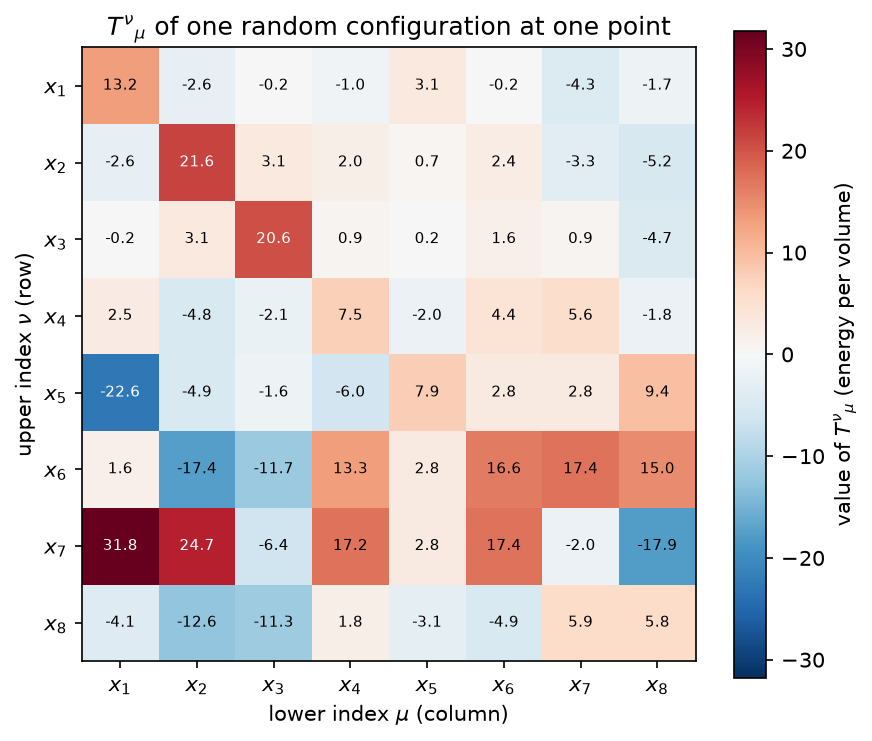

Figure 09a.2 saved as Revision/textbook/figures/09a_2_tensor_heat_map.png


In [8]:
fig, ax = plt.subplots(figsize=(6.6, 5.6))
largest = np.abs(T).max()  # the colour scale runs from -largest to +largest
picture = ax.imshow(T, cmap="RdBu_r", vmin=-largest, vmax=largest)
for nu in range(8):
    for mu in range(8):
        # white digits on dark squares, black digits on light ones
        colour = "white" if abs(T[nu, mu]) > 0.6 * largest else "black"
        ax.text(mu, nu, f"{T[nu, mu]:.1f}", ha="center", va="center", fontsize=7,
                color=colour)
ax.set_xticks(range(8), [f"${n[0]}_{n[1]}$" for n in NAMES])
ax.set_yticks(range(8), [f"${n[0]}_{n[1]}$" for n in NAMES])
ax.set_xlabel("lower index $\\mu$ (column)")
ax.set_ylabel("upper index $\\nu$ (row)")
ax.set_title("$T^\\nu{}_\\mu$ of one random configuration at one point")
ax.grid(False)  # no grid lines across the squares
fig.colorbar(picture, ax=ax, label="value of $T^\\nu{}_\\mu$ (energy per volume)")
save_figure(fig, "tensor_heat_map",
            "Heat map of the energy-momentum tensor $T^\\nu{}_\\mu$ of a random "
            "configuration of dirac16complex00 at the point $a_4 = 0.5$, "
            "$a_4' = 0.25$, $z = \\pi/4$ of the deflating history, with $H = 0.25$, "
            "$m = 1$, $\\lambda = 0.5$; row $\\nu$ and column $\\mu$ run over "
            "$x_1, \\dots, x_8$; colour and printed number give the value, in units "
            "of energy per unit volume. The diagonal holds $-\\rho$ at $x_4$ and "
            "the seven pressures; the off-diagonal squares are flows of energy and "
            "momentum. The table is not symmetric as printed, because the upper "
            "index is raised with the metric; $g_{\\nu\\nu}T^\\nu{}_\\mu$ is "
            "symmetric.")

## 9. The diagonal entries: energy density, pressures, kinetic and potential parts

The next cell checks the record's statement $T^\mu{}_\mu = L_0 - K_\mu$ for all
eight directions and $L_0 = \sum_\mu K_\mu - mS - U$. It then computes the energy
density and the pressures and splits each into its kinetic part (made of the
$K_\nu$) and its potential part ($mS + U$):
$\rho = \rho_{\rm kin} + \rho_{\rm pot}$ with
$\rho_{\rm kin} = -\sum_{\mu \neq x_4}K_\mu$, $\rho_{\rm pot} = mS + U$, and
$p_\mu = \sum_{\nu \neq \mu}K_\nu - (mS + U)$. A random configuration is not
isotropic, so the three 3-space pressures differ, and so do the three extra-time
pressures. Its energy density may come out negative: the energy of
dirac16complex00 has no lower bound (Revision record
`Revision/theory/reports/python-scope.json`, check
`commuting_field_energy_unbounded_below`), because both $S$ and the kinetic
terms can have either sign.

In [9]:
THEORY_WL = "Revision/theory/reports/wolfram-field-theory.json"
check(np.abs(np.diag(T) - (L0 - K)).max() < 1e-12
      and abs(L0 - (K.sum() - m * S - U)) < 1e-12
      and recorded(THEORY_WL, "T_diagonal_components_C") == "PASS",
      "T^mu_mu = L0 - K_mu for all eight mu, and L0 = sum K - m S - U",
      record=f"{THEORY_WL}, check T_diagonal_components_C")
potential = m * S + U  # the potential energy density m S + U(S)
# kinetic part of T^mu_mu: the sum of the K_nu with nu different from mu
kinetic_parts = np.array([K.sum() - K[mu] for mu in range(8)])
rho = -T[3, 3]  # the energy density
rho_kin = -(K.sum() - K[3])  # minus the sum of the K_mu with mu different from x4
check(abs(rho - (rho_kin + potential)) < 1e-12
      and np.abs(np.diag(T) - (kinetic_parts - potential)).max() < 1e-12,
      "rho = rho_kin + rho_pot and p_mu = (sum of the other K) - (m S + U)")
report("rho = -T^x4_x4", f"{rho:.6f}")
report("rho_kin", f"{rho_kin:.6f}")
report("rho_pot = m S + U", f"{potential:.6f}")
for mu in (0, 1, 2, 4, 5, 6, 7):
    report(f"pressure T^{NAMES[mu]}_{NAMES[mu]}", f"{T[mu, mu]:.6f}")

PASS T^mu_mu = L0 - K_mu for all eight mu, and L0 = sum K - m S - U
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    T_diagonal_components_C
PASS rho = rho_kin + rho_pot and p_mu = (sum of the other K) - (m S + U)
RESULT rho = -T^x4_x4 = -7.531406
RESULT rho_kin = -11.656818
RESULT rho_pot = m S + U = 4.125412
RESULT pressure T^x1_x1 = 13.160483
RESULT pressure T^x2_x2 = 21.578866
RESULT pressure T^x3_x3 = 20.599843
RESULT pressure T^x5_x5 = 7.938088
RESULT pressure T^x6_x6 = 16.584797
RESULT pressure T^x7_x7 = -1.976597
RESULT pressure T^x8_x8 = 5.772126


The next cell draws, for each direction, the kinetic part, the potential part and
their sum, the diagonal entry $T^\mu{}_\mu$. The potential part is the same,
$-(mS + U)$, in every direction; the kinetic parts differ.

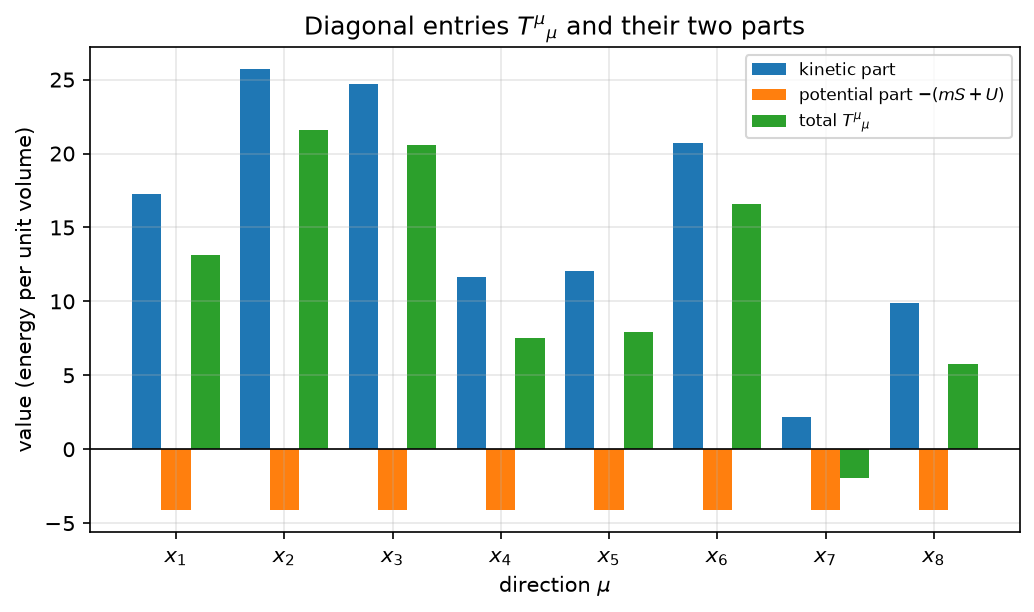

Figure 09a.3 saved as Revision/textbook/figures/09a_3_diagonal_parts.png


In [10]:
positions = np.arange(8)  # one group of bars per direction
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(positions - 0.27, kinetic_parts, width=0.27, label="kinetic part")
ax.bar(positions, [-potential] * 8, width=0.27, label="potential part $-(mS + U)$")
ax.bar(positions + 0.27, np.diag(T), width=0.27, label="total $T^\\mu{}_\\mu$")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(positions, [f"${n[0]}_{n[1]}$" for n in NAMES])
ax.set_xlabel("direction $\\mu$")
ax.set_ylabel("value (energy per unit volume)")
ax.set_title("Diagonal entries $T^\\mu{}_\\mu$ and their two parts")
ax.legend(fontsize=8)
save_figure(fig, "diagonal_parts",
            "The eight diagonal entries $T^\\mu{}_\\mu$ (right bar of each group) "
            "of the random configuration of the previous figure, each split into "
            "its kinetic part, the sum of the kinetic terms $K_\\nu$ of the other "
            "seven directions (left bar), and its potential part $-(mS + U)$ "
            "(middle bar), in units of energy per unit volume. The potential part "
            "is the same in every direction; the entry at $x_4$ is $-\\rho$, and "
            "the others are the pressures $p_3$ (three of them), $p_t$ (three) "
            "and $p_8$.")

## 10. The trace, the kinetic sum, and the configuration put on shell

Summing $T^\mu{}_\mu = L_0 - K_\mu$ over the eight directions gives
$8L_0 - \sum_\mu K_\mu = 7\sum_\mu K_\mu - 8(mS + U)$ (the record's trace
identity). The record also states, for every configuration, the kinetic-sum
identity $\sum_\mu K_\mu = VS + \frac12(\bar\Phi E - \bar E\Phi)$ with
$V = m + U'(S) = m + \lambda S$, the field-equation expression
$E = \gamma^\mu D_\mu\Phi - V\Phi$ and its adjoint
$\bar E = (D_\mu\bar\Phi)\gamma^\mu + V\bar\Phi$. The next cell checks both.

Then it puts the configuration on shell at the point: the field equation can be
solved for the time derivative (its evolution form),
$\partial_4\Phi = -\gamma^{(4)}\big[V\Phi - \sum_{a \neq 4}\frac{1}{f_a}\gamma^{(a)}
\partial_a\Phi - 3H\gamma^{(8)}\Phi\big]$; the cell replaces the random
$\partial_4\Phi$ by this one, checks that $E = 0$, and checks the on-shell values
$\sum_\mu K_\mu = VS$, $L_0 = SU' - U$ and
$T^\mu{}_\mu = -mS + 7SU' - 8U = -mS + 3\lambda S^2$.

In [11]:
V = m + lam * S  # V = m + U'(S), with U'(S) = lambda S
E = sum(gamma_up[mu] @ (dPhi[mu] + Omega[mu] @ Phi) for mu in range(8)) - V * Phi
E_bar = sum((bar(dPhi[mu]) - bar(Phi) @ Omega[mu]) @ gamma_up[mu]
            for mu in range(8)) + V * bar(Phi)
check(abs(np.trace(T) - (7 * K.sum() - 8 * (m * S + U))) < 1e-11
      and recorded(THEORY_WL, "EMT_trace_C") == "PASS",
      "trace: sum of T^mu_mu = 7 sum K - 8 (m S + U), off shell",
      record=f"{THEORY_WL}, check EMT_trace_C")
kinetic_sum = V * S + 0.5 * (bar(Phi) @ E - E_bar @ Phi)
check(abs(K.sum() - kinetic_sum) < 1e-11
      and recorded(THEORY_WL, "kinetic_sum_on_shell_C") == "PASS",
      "sum K = V S + (1/2)(Phibar E - Ebar Phi), off shell",
      record=f"{THEORY_WL}, check kinetic_sum_on_shell_C")
report("|E| of the random configuration (it is off shell)",
       f"{np.linalg.norm(E):.6f}")
# The evolution form of the field equation gives d4 Phi from the other derivatives.
rest = sum(gamma[a] @ dPhi[a] / f[a] for a in range(8) if a != 3)
dPhi_on = dPhi.copy()
dPhi_on[3] = -gamma[3] @ (V * Phi - rest - 3 * H * gamma[7] @ Phi)
E_on = sum(gamma_up[mu] @ (dPhi_on[mu] + Omega[mu] @ Phi) for mu in range(8)) - V * Phi
S_on, U_on, L0_on, K_on, T_on = energy_momentum(Phi, dPhi_on, f, gamma_up, gamma_down,
                                                Omega)
check(np.abs(E_on).max() < 1e-12, "with d4 Phi from the evolution form, E = 0")
check(abs(K_on.real.sum() - V * S) < 1e-11
      and abs(L0_on.real - (S * lam * S - U)) < 1e-11
      and abs(np.trace(T_on.real) - (-m * S + 3 * lam * S ** 2)) < 1e-10
      and recorded(THEORY_PY, "commuting_trace_on_shell") == "PASS",
      "on shell: sum K = V S, L0 = S U' - U, trace = -m S + 3 lambda S^2",
      record=f"{THEORY_PY}, check commuting_trace_on_shell")
report("trace on shell, -m S + 3 lambda S^2", f"{np.trace(T_on.real):.6f}")

PASS trace: sum of T^mu_mu = 7 sum K - 8 (m S + U), off shell
     reproduces Revision/theory/reports/wolfram-field-theory.json, check EMT_trace_C
PASS sum K = V S + (1/2)(Phibar E - Ebar Phi), off shell
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    kinetic_sum_on_shell_C
RESULT |E| of the random configuration (it is off shell) = 19.335808
PASS with d4 Phi from the evolution form, E = 0
PASS on shell: sum K = V S, L0 = S U' - U, trace = -m S + 3 lambda S^2
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_trace_on_shell
RESULT trace on shell, -m S + 3 lambda S^2 = 70.447596


## 11. Where the spin connection does enter the tensor

The spin connection drops out of the Lagrangian and of the diagonal entries.
It does enter off-diagonal entries. Take a homogeneous configuration (it depends
on $x_4$ only, so $\partial_\mu\Phi = 0$ for $\mu \neq x_4$). In the piece
$K^{x_4}{}_{x_1} = \frac12(\bar\Phi\gamma^{x_4}D_{x_1}\Phi
- D_{x_1}\bar\Phi \gamma^{x_4}\Phi)$ of $T^{x_4}{}_{x_1}$ the derivative part
vanishes and only the connection part
$\frac12\bar\Phi\{\gamma^{x_4}, \Omega_{x_1}\}\Phi$ is left; the record states
that it equals $\frac12 e^{a_4}\sin^{1/6}z H \bar\Phi\gamma^{(4)}\gamma^{(1)}
\gamma^{(8)}\Phi$ (the $a_4'$ part cancels). The next cell checks this at the
point.

In [12]:
dPhi_hom = np.zeros((8, 16), dtype=complex)  # homogeneous: only d4 Phi is nonzero
dPhi_hom[3] = rng.normal(size=16) + 1j * rng.normal(size=16)
D_x1 = dPhi_hom[0] + Omega[0] @ Phi  # D_x1 Phi = Omega_x1 Phi here
Dbar_x1 = bar(dPhi_hom[0]) - bar(Phi) @ Omega[0]  # D_x1 Phibar = -Phibar Omega_x1
K_41 = 0.5 * (bar(Phi) @ gamma_up[3] @ D_x1 - Dbar_x1 @ gamma_up[3] @ Phi)
expected = 0.5 * np.exp(a4) * np.sin(z) ** (1 / 6) * H * (
    bar(Phi) @ gamma[3] @ gamma[0] @ gamma[7] @ Phi)
SCOPE_PY = "Revision/theory/reports/python-scope.json"
SCOPE_WL = "Revision/theory/reports/wolfram-scope.json"
check(abs(K_41 - expected) < 1e-12 and abs(K_41) > 0.01
      and recorded(SCOPE_PY, "spin_connection_in_the_energy_momentum_tensor") == "PASS"
      and recorded(SCOPE_WL, "spin_connection_in_the_energy_momentum_tensor") == "PASS",
      "K^x4_x1 of a homogeneous configuration is the nonzero connection term",
      record=f"{SCOPE_PY} and {SCOPE_WL}, check "
             "spin_connection_in_the_energy_momentum_tensor")
report("K^x4_x1 (homogeneous configuration)", f"{K_41.real:.6f}")

PASS K^x4_x1 of a homogeneous configuration is the nonzero connection term
     reproduces Revision/theory/reports/python-scope.json and
    Revision/theory/reports/wolfram-scope.json, check
    spin_connection_in_the_energy_momentum_tensor
RESULT K^x4_x1 (homogeneous configuration) = -0.203311


## 12. The Christoffel symbols of the author's metric (exact, with sympy)

From here on the notebook computes exactly with symbols. For a diagonal metric
the Christoffel symbols are
$\Gamma^\lambda{}_{\mu\nu} = \frac{1}{2g_{\lambda\lambda}}(\partial_\mu
g_{\lambda\nu} + \partial_\nu g_{\lambda\mu} - \partial_\lambda g_{\mu\nu})$
(no sum over $\lambda$). The next cell writes the author's metric with symbols
(a general function $a_4(x_4)$, the symbol $H$) and computes all the symbols with
$\mu \le \nu$ (the symbol is symmetric in $\mu$ and $\nu$), keeping the nonzero
ones in a dictionary. It prints how many it found.

In [13]:
import sympy as sp  # exact algebra and calculus with symbols

x = sp.symbols("x1:9", real=True)  # the coordinates x1, ..., x8 (x[0] ... x[7])
Hs = sp.symbols("H", positive=True)  # the author's constant, as a symbol
a4_function = sp.Function("a4")(x[3])  # a general function a4(x4)
zs = 6 * Hs * x[7]  # z = 6 H x8
space_entry = sp.exp(2 * a4_function) * sp.sin(zs) ** sp.Rational(1, 3)
extra_entry = -sp.exp(-2 * a4_function) * sp.sin(zs) ** sp.Rational(1, 3)
g = sp.diag(*([space_entry] * 3 + [-1] + [extra_entry] * 3 + [sp.cot(zs) ** 2]))
christoffel = {}  # (lambda, mu, nu) -> Gamma^lambda_mu nu, only the nonzero ones
for l in range(8):
    for i in range(8):
        for j in range(i, 8):  # mu <= nu
            value = sp.simplify((sp.diff(g[l, j], x[i]) + sp.diff(g[l, i], x[j])
                                 - sp.diff(g[i, j], x[l])) / (2 * g[l, l]))
            if value != 0:
                christoffel[(l, i, j)] = value
say(f"{len(christoffel)} nonzero Christoffel symbols with mu <= nu")

25 nonzero Christoffel symbols with mu <= nu


The record lists exactly 25 such symbols (`Revision/theory/field-theory.json`,
formula `christoffel_nonzero`, written in the Wolfram Language). The next cell
translates that text into sympy's notation with the function `from_wolfram`, by
plain text replacements (for example `Sin[` becomes `sin(` and
`Derivative[1][a4][x4]` becomes `a4p`); the function `plain` writes our own
symbols with the same plain names `a4` and `a4p`. The cell compares the two lists
symbol by symbol and prints the 25 symbols.

In [14]:
a4s, a4ps = sp.symbols("a4 a4p", real=True)  # plain symbols for a4 and da4/dx4


def plain(expression):
    """Replace da4/dx4 by the symbol a4p and a4(x4) by the symbol a4."""
    return expression.subs(sp.Derivative(a4_function, x[3]), a4ps).subs(
        a4_function, a4s)


WOLFRAM_TO_SYMPY = [  # (Wolfram text, sympy text), applied in this order
    ("Derivative[1][a4][x4]", "a4p"), ("Derivative[1, 0][rho][x4, x8]", "rho_4"),
    ("Derivative[0, 1][p8][x4, x8]", "p8_8"), ("[x4, x8]", ""), ("a4[x4]", "a4"),
    ("Sin[", "sin("), ("Cos[", "cos("), ("Cot[", "cot("), ("Sec[", "sec("),
    ("Csc[", "csc("), ("E^", "E**"), ("^", "**"), ("[", "("), ("]", ")"),
    ("{", "["), ("}", "]")]


def from_wolfram(text):
    """Translate a formula of the record from the Wolfram Language into sympy."""
    for old, new in WOLFRAM_TO_SYMPY:
        text = text.replace(old, new)
    return text


FORMULAS = {item["key"]: item["wl"] for item in json.loads(repository_file(
    "Revision/theory/field-theory.json").read_text(encoding="utf-8"))["formulas"]}
NAMES_SYMPY = {"a4": a4s, "a4p": a4ps, "H": Hs, "x8": x[7], "E": sp.E}
record_list = sp.sympify(from_wolfram(FORMULAS["christoffel_nonzero"]),
                         locals=NAMES_SYMPY)
# The record counts the coordinates 1 ... 8; Python counts 0 ... 7.
record_symbols = {(int(e[0]) - 1, int(e[1]) - 1, int(e[2]) - 1): e[3]
                  for e in record_list}
same = sorted(record_symbols) == sorted(christoffel) and all(
    sp.simplify(plain(christoffel[key]) - record_symbols[key]) == 0
    for key in christoffel)
check(len(christoffel) == 25 and same
      and recorded(THEORY_WL, "christoffel_count") == "PASS",
      "25 nonzero Christoffel symbols, equal to the record's list one by one",
      record=f"{THEORY_WL}, check christoffel_count (formula christoffel_nonzero)")
for (l, i, j), value in sorted(christoffel.items()):
    print(f"Gamma^{NAMES[l]}_({NAMES[i]} {NAMES[j]}) = {plain(value)}")

PASS 25 nonzero Christoffel symbols, equal to the record's list one by one
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    christoffel_count (formula christoffel_nonzero)
Gamma^x1_(x1 x4) = a4p
Gamma^x1_(x1 x8) = H/tan(6*H*x8)
Gamma^x2_(x2 x4) = a4p
Gamma^x2_(x2 x8) = H/tan(6*H*x8)
Gamma^x3_(x3 x4) = a4p
Gamma^x3_(x3 x8) = H/tan(6*H*x8)
Gamma^x4_(x1 x1) = a4p*exp(2*a4)*sin(6*H*x8)**(1/3)
Gamma^x4_(x2 x2) = a4p*exp(2*a4)*sin(6*H*x8)**(1/3)
Gamma^x4_(x3 x3) = a4p*exp(2*a4)*sin(6*H*x8)**(1/3)
Gamma^x4_(x5 x5) = a4p*exp(-2*a4)*sin(6*H*x8)**(1/3)
Gamma^x4_(x6 x6) = a4p*exp(-2*a4)*sin(6*H*x8)**(1/3)
Gamma^x4_(x7 x7) = a4p*exp(-2*a4)*sin(6*H*x8)**(1/3)
Gamma^x5_(x4 x5) = -a4p
Gamma^x5_(x5 x8) = H/tan(6*H*x8)
Gamma^x6_(x4 x6) = -a4p
Gamma^x6_(x6 x8) = H/tan(6*H*x8)
Gamma^x7_(x4 x7) = -a4p
Gamma^x7_(x7 x8) = H/tan(6*H*x8)
Gamma^x8_(x1 x1) = -H*exp(2*a4)*sin(6*H*x8)**(4/3)/cos(6*H*x8)
Gamma^x8_(x2 x2) = -H*exp(2*a4)*sin(6*H*x8)**(4/3)/cos(6*H*x8)
Gamma^x8_(x3 x3) = -

## 13. The covariant divergence of a diagonal tensor: the two identities

For a tensor $T^\mu{}_\nu$ the covariant divergence is
$\nabla_\mu T^\mu{}_\nu = \partial_\mu T^\mu{}_\nu + \Gamma^\mu{}_{\mu\lambda}
T^\lambda{}_\nu - \Gamma^\lambda{}_{\mu\nu}T^\mu{}_\lambda$ (sums over $\mu$ and
$\lambda$). The next cell takes the diagonal tensor
$\mathrm{diag}(p_3, p_3, p_3, -\rho, p_t, p_t, p_t, p_8)$ whose four entries are
arbitrary functions of $x_4$ and $x_8$ and computes the eight components with the
Christoffel symbols of the previous section. It prints which components are not
identically zero.

In [15]:
rho_f, p3_f, pt_f, p8_f = [sp.Function(n)(x[3], x[7]) for n in ("rho", "p3", "pt",
                                                                 "p8")]
T_diag = sp.diag(p3_f, p3_f, p3_f, -rho_f, pt_f, pt_f, pt_f, p8_f)  # T^mu_nu


def gamma_symbol(l, i, j):
    """Gamma^l_ij for any order of i and j (zero when it is not in the list)."""
    return christoffel.get((l, min(i, j), max(i, j)), 0)


divergence = []
for nu in range(8):
    value = sum(sp.diff(T_diag[mu, nu], x[mu]) for mu in range(8))
    value += sum(gamma_symbol(mu, mu, l) * T_diag[l, nu]
                 for mu in range(8) for l in range(8))
    value -= sum(gamma_symbol(l, mu, nu) * T_diag[mu, l]
                 for mu in range(8) for l in range(8))
    divergence.append(sp.simplify(value))
nonzero = [NAMES[nu] for nu in range(8) if divergence[nu] != 0]
say("components of the divergence that are not identically zero: nu = "
    + ", ".join(nonzero))

components of the divergence that are not identically zero: nu = x4, x8


The record (formula `energy_exchange`, and the lead's independent check) says:
$\nabla_\mu T^\mu{}_{x_4} = -\partial_4\rho - 3a_4'(p_3 - p_t)$,
$\nabla_\mu T^\mu{}_{x_8} = \partial_8 p_8 + 3H\cot z (2p_8 - p_3 - p_t)$, and
the other six components vanish identically. The next cell writes our eight
components with the record's plain names (`rho_4` for $\partial_4\rho$, `p8_8`
for $\partial_8 p_8$), translates the record's formula, and checks all eight
components against it and against these two lines.

In [16]:
rho_4, p8_8, p3s, pts, p8s = sp.symbols("rho_4 p8_8 p3 pt p8", real=True)


def plain_t(expression):
    """Write the derivatives and functions as the plain symbols of the record."""
    expression = expression.subs({sp.Derivative(rho_f, x[3]): rho_4,
                                  sp.Derivative(p8_f, x[7]): p8_8})
    expression = expression.subs({p3_f: p3s, pt_f: pts, p8_f: p8s,
                                  rho_f: sp.Symbol("rho", real=True)})
    return plain(expression)


NAMES_T = dict(NAMES_SYMPY, rho_4=rho_4, p8_8=p8_8, p3=p3s, pt=pts, p8=p8s)
record_divergence = sp.sympify(from_wolfram(FORMULAS["energy_exchange"][0]),
                               locals=NAMES_T)
agree = all(sp.simplify(plain_t(divergence[n]) - record_divergence[n]) == 0
            for n in range(8))
x4_line = -rho_4 - 3 * a4ps * (p3s - pts)
x8_line = p8_8 + 3 * Hs * sp.cot(zs) * (2 * p8s - p3s - pts)
check(agree and recorded(THEORY_WL, "energy_exchange_equation") == "PASS"
      and recorded(THEORY_PY, "energy_exchange_equation") == "PASS",
      "the eight components agree with the record formula energy_exchange",
      record=f"{THEORY_WL} and {THEORY_PY}, check energy_exchange_equation")
check(sp.simplify(plain_t(divergence[3]) - x4_line) == 0
      and recorded(LEAD, "divergence_x4_component") == "PASS",
      "nabla_mu T^mu_x4 = -d4 rho - 3 a4p (p3 - p_t)",
      record=f"{LEAD}, check divergence_x4_component")
check(sp.simplify(plain_t(divergence[7]) - x8_line) == 0
      and recorded(LEAD, "divergence_x8_component") == "PASS",
      "nabla_mu T^mu_x8 = d8 p8 + 3 H cot z (2 p8 - p3 - p_t)",
      record=f"{LEAD}, check divergence_x8_component")
check(all(divergence[n] == 0 for n in (0, 1, 2, 4, 5, 6))
      and recorded(LEAD, "divergence_other_components_zero") == "PASS",
      "the components x1, x2, x3, x5, x6, x7 vanish identically",
      record=f"{LEAD}, check divergence_other_components_zero")
print("nabla_mu T^mu_x4 =", x4_line)  # rho_4 = d rho/d x4
print("nabla_mu T^mu_x8 =", x8_line)  # p8_8 = d p8/d x8

PASS the eight components agree with the record formula energy_exchange
     reproduces Revision/theory/reports/wolfram-field-theory.json and
    Revision/theory/reports/python-field-theory.json, check energy_exchange_equation
PASS nabla_mu T^mu_x4 = -d4 rho - 3 a4p (p3 - p_t)
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check divergence_x4_component
PASS nabla_mu T^mu_x8 = d8 p8 + 3 H cot z (2 p8 - p3 - p_t)
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check divergence_x8_component
PASS the components x1, x2, x3, x5, x6, x7 vanish identically
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check divergence_other_components_zero
nabla_mu T^mu_x4 = -3*a4p*(p3 - pt) - rho_4
nabla_mu T^mu_x8 = 3*H*(-p3 + 2*p8 - pt)*cot(6*H*x8) + p8_8


## 14. The x4 identity read as a first law

Conservation, $\nabla_\mu T^\mu{}_{x_4} = 0$, says
$\partial_4\rho = -3a_4'(p_3 - p_t)$. Here is why. At fixed $x_8$ take a small
box of coordinate size 1 in each of the seven directions other than $x_4$. Its
3-space volume is $V_3 = f_1 f_2 f_3 = e^{3a_4}\sin^{1/2}z$, its extra-time
volume $V_t = f_5 f_6 f_7 = e^{-3a_4}\sin^{1/2}z$, and its 7-volume
$V_7 = V_3 V_t f_8 = \cos z$ does not change with $x_4$. The first law of
thermodynamics (energy changes by minus pressure times change of volume), applied
to each family of directions, would say that the energy $\rho V_7$ in the box
changes as
$\frac{d}{dx_4}(\rho V_7) = -p_3\frac{V_7}{V_3}\frac{dV_3}{dx_4}
- p_t\frac{V_7}{V_t}\frac{dV_t}{dx_4}$. The next cell checks with sympy that this
is exactly the conservation identity. This is a reading of the identity (an
interpretation, not an extra result): dividing by the constant $V_7$,
$d\rho = -p_3\,dV_3/V_3 - p_t\,dV_t/V_t$. While 3-space inflates ($dV_3 > 0$) a
positive $p_3$ takes energy out of the box; while the extra times deflate
($dV_t < 0$) a positive $p_t$ puts energy in. The energy density stays constant
only if $p_3 = p_t$.

In [17]:
f_space = sp.exp(a4_function) * sp.sin(zs) ** sp.Rational(1, 6)  # f1 = f2 = f3
f_extra = sp.exp(-a4_function) * sp.sin(zs) ** sp.Rational(1, 6)  # f5 = f6 = f7
V3 = f_space ** 3  # e^(3 a4) sin^(1/2) z
Vt = f_extra ** 3  # e^(-3 a4) sin^(1/2) z
V7 = V3 * Vt * sp.cot(zs)  # times f8 = cot z (and f4 = 1)
check(sp.simplify(V7 - sp.cos(zs)) == 0, "V3 Vt f8 = cos z, independent of x4")
first_law = (sp.diff(rho_f * V7, x[3]) + p3_f * V7 / V3 * sp.diff(V3, x[3])
             + pt_f * V7 / Vt * sp.diff(Vt, x[3]))
# The first law says first_law = 0; it must be -V7 times the x4 divergence.
check(sp.simplify(first_law + V7 * divergence[3]) == 0,
      "d(rho V7)/dx4 + p3 (V7/V3) dV3/dx4 + p_t (V7/Vt) dVt/dx4 = -V7 nabla_mu T^mu_x4")

PASS V3 Vt f8 = cos z, independent of x4
PASS d(rho V7)/dx4 + p3 (V7/V3) dV3/dx4 + p_t (V7/Vt) dVt/dx4 = -V7 nabla_mu T^mu_x4


The next cell draws the three volumes along the deflating history
$a_4 = AHx_4$ ($A = 1$, $H = 0.25$) for $x_4$ from $0$ to $8$, each divided by its
value at $x_4 = 0$: $V_3$ grows like $e^{3AHx_4}$, $V_t$ shrinks like
$e^{-3AHx_4}$, and $V_7$ stays 1.

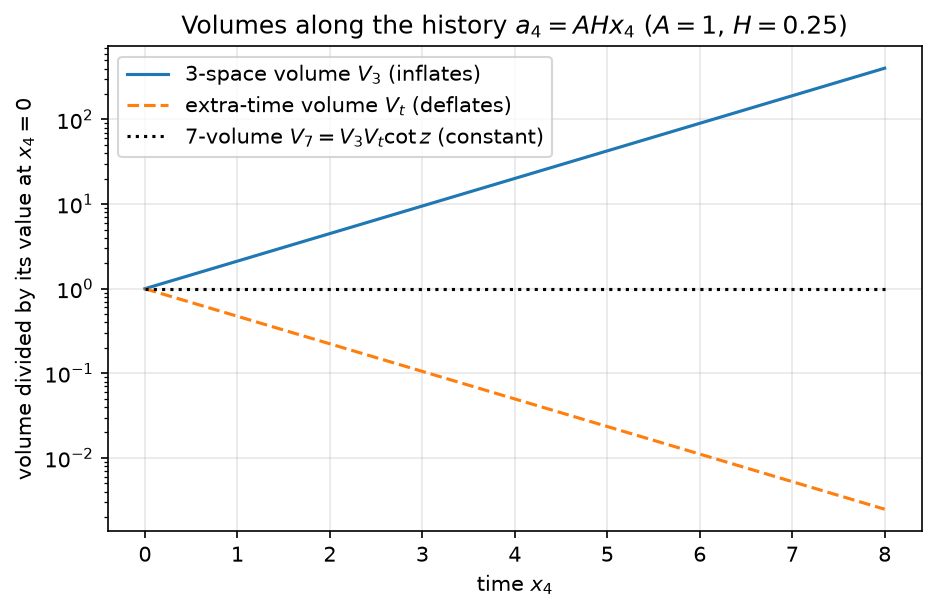

Figure 09a.4 saved as Revision/textbook/figures/09a_4_volumes_first_law.png


In [18]:
x4_axis = np.linspace(0.0, 8.0, 401)  # the time x4
growth = np.exp(3 * A * H * x4_axis)  # V3(x4)/V3(0) = e^(3 A H x4)
fig, ax = plt.subplots()
ax.plot(x4_axis, growth, label="3-space volume $V_3$ (inflates)")
ax.plot(x4_axis, 1 / growth, "--", label="extra-time volume $V_t$ (deflates)")
ax.plot(x4_axis, growth / growth, ":", color="black",
        label="7-volume $V_7 = V_3 V_t \\cot z$ (constant)")
ax.set_yscale("log")
ax.set_xlabel("time $x_4$")
ax.set_ylabel("volume divided by its value at $x_4 = 0$")
ax.set_title("Volumes along the history $a_4 = A H x_4$ ($A = 1$, $H = 0.25$)")
ax.legend()
save_figure(fig, "volumes_first_law",
            "The 3-space volume $V_3 = e^{3a_4}\\sin^{1/2}z$ (solid), the "
            "extra-time volume $V_t = e^{-3a_4}\\sin^{1/2}z$ (dashed) and the "
            "7-volume $V_7 = \\cos z$ (dotted) of a coordinate box at fixed $x_8$, "
            "along the deflating history $a_4 = AHx_4$ with $A = 1$, $H = 0.25$, "
            "for $x_4$ from $0$ to $8$, each divided by its value at $x_4 = 0$; "
            "logarithmic vertical axis. The growth of $V_3$ and the shrinking of "
            "$V_t$ cancel exactly. Read as a first law, the conservation identity "
            "$d\\rho/dx_4 = -3a_4'(p_3 - p_t)$ says: while 3-space inflates a "
            "positive $p_3$ takes energy out of the box, while the extra times "
            "deflate a positive $p_t$ puts energy in, and the two balance only "
            "when $p_3 = p_t$.")

## 15. The x8 identity: the balance along the hidden direction

Conservation along $x_8$ says
$\partial_8 p_8 = -3H\cot z (2p_8 - p_3 - p_t)$, a balance of pressures like
the balance of pressure and weight in a column of air. If the entries do not
depend on $x_8$, it forces $p_8 = (p_3 + p_t)/2$. If $p_3 + p_t = P$ is a
constant, every solution is $p_8 = P/2 + c/\sin z$ with a constant $c$; only
$c = 0$ is independent of $x_8$. The next cell checks this with sympy, then the
same identity in the hidden coordinate $y = \ln(\sin z)/(6H)$ used by the
Kohn-Sham solver of the book: $dy/dx_8 = \cot z$, and the $x_8$ component is
$\cot z [p_8'(y) + 6Hp_8 - 3H(p_3 + p_t)]$ (the lead's checks).

In [19]:
P, c = sp.symbols("P c", real=True)  # P = p3 + p_t (a constant) and the constant c
profile = P / 2 + c / sp.sin(zs)  # p8 as a function of x8 (through z)
balance = sp.diff(profile, x[7]) + 3 * Hs * sp.cot(zs) * (2 * profile - P)
check(sp.simplify(balance) == 0,
      "p8 = P/2 + c/sin z solves the x8 identity for every c")
y = sp.symbols("y", real=True)
dy_dx8 = sp.diff(sp.log(sp.sin(zs)) / (6 * Hs), x[7])  # y = ln(sin z)/(6 H)
check(sp.simplify(dy_dx8 - sp.cot(zs)) == 0
      and recorded(LEAD, "ks_coordinate_jacobian") == "PASS",
      "y = ln(sin z)/(6 H) has dy/dx8 = cot z",
      record=f"{LEAD}, check ks_coordinate_jacobian")
z_of_y = sp.asin(sp.exp(6 * Hs * y))  # sin z = e^(6 H y), z between 0 and pi/2
P8, P3, PT = [sp.Function(n)(y) for n in ("P8", "P3", "PT")]
in_x8 = sp.cot(z_of_y) * sp.diff(P8, y) + 3 * Hs * sp.cot(z_of_y) * (2 * P8 - P3 - PT)
in_y = sp.cot(z_of_y) * (sp.diff(P8, y) + 6 * Hs * P8 - 3 * Hs * (P3 + PT))
check(sp.simplify(in_x8 - in_y) == 0
      and recorded(LEAD, "ks_coordinate_form") == "PASS",
      "x8 component = cot z [p8'(y) + 6 H p8 - 3 H (p3 + p_t)]",
      record=f"{LEAD}, check ks_coordinate_form")

PASS p8 = P/2 + c/sin z solves the x8 identity for every c
PASS y = ln(sin z)/(6 H) has dy/dx8 = cot z
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check ks_coordinate_jacobian
PASS x8 component = cot z [p8'(y) + 6 H p8 - 3 H (p3 + p_t)]
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check ks_coordinate_form


The next cell draws the profiles $p_8 = P/2 + c/\sin z$ for $P = 1$ and five
values of $c$, and checks numerically on the drawn grid (with numpy's
`np.gradient`, a finite-difference derivative) that each profile satisfies the
balance: the left side minus the right side is small compared with the terms.

PASS the drawn profiles satisfy the x8 balance on the grid


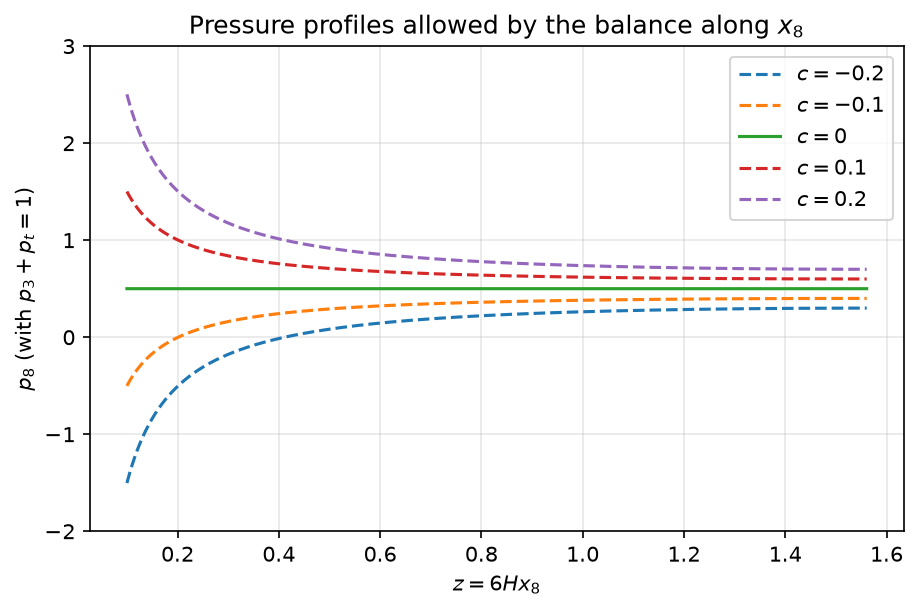

Figure 09a.5 saved as Revision/textbook/figures/09a_5_hidden_balance.png
RESULT largest relative residual of the balance on the grid = 2.3e-05


In [20]:
z_grid = np.linspace(0.1, np.pi / 2 - 0.01, 2001)  # z from 0.1 to just below pi/2
x8_grid = z_grid / (6 * H)  # the matching x8 = z/(6 H)
fig, ax = plt.subplots()
worst = 0.0  # the largest relative residual of the balance on the grid
for c_value in (-0.2, -0.1, 0.0, 0.1, 0.2):
    p8_values = 0.5 + c_value / np.sin(z_grid)  # P = 1
    slope = np.gradient(p8_values, x8_grid)  # d p8/d x8, by finite differences
    rhs = -3 * H / np.tan(z_grid) * (2 * p8_values - 1.0)
    # The size of the terms; 1 (the size of P) is added, so that for the flat
    # profile c = 0, whose terms are zero, rounding noise is not divided by zero.
    scale = 1.0 + np.abs(slope).max() + np.abs(rhs).max()
    # [5:-5] leaves out five points at each end, where np.gradient is less exact.
    worst = max(worst, np.abs(slope - rhs)[5:-5].max() / scale)
    style = "-" if c_value == 0.0 else "--"
    ax.plot(z_grid, p8_values, style, label=f"$c = {c_value:g}$")  # g: short form
check(worst < 1e-4, "the drawn profiles satisfy the x8 balance on the grid")
ax.set_ylim(-2.0, 3.0)
ax.set_xlabel("$z = 6 H x_8$")
ax.set_ylabel("$p_8$ (with $p_3 + p_t = 1$)")
ax.set_title("Pressure profiles allowed by the balance along $x_8$")
ax.legend()
save_figure(fig, "hidden_balance",
            "The hidden-direction pressure profiles $p_8 = P/2 + c/\\sin z$ that "
            "satisfy the conservation identity along $x_8$, "
            "$\\partial_8 p_8 = -3H\\cot z\\,(2p_8 - p_3 - p_t)$, when "
            "$p_3 + p_t = P = 1$ is constant, for $c = -0.2, -0.1, 0, 0.1, 0.2$; "
            "horizontal axis $z = 6Hx_8$ from $0.1$ to just below $\\pi/2$, "
            "vertical axis $p_8$ in units of energy per unit volume. Only $c = 0$ "
            "(solid line) is independent of $x_8$, and it has $p_8 = P/2 = "
            "(p_3 + p_t)/2$; every other profile grows in size like $1/\\sin z$ "
            "towards the tip $z = 0$ (upwards for $c > 0$, downwards for $c < 0$).")
report("largest relative residual of the balance on the grid", f"{worst:.1e}")

## 16. The last check

The last cell checks that the five figures are saved with their captions and
prints the number of checks that passed.

In [21]:
captions = json.loads(output_file(CAPTION_FILE).read_text(encoding="utf-8"))
expected_files = ["09a_1_kinetic_weights.png", "09a_2_tensor_heat_map.png",
                  "09a_3_diagonal_parts.png", "09a_4_volumes_first_law.png",
                  "09a_5_hidden_balance.png"]
check(sorted(captions) == expected_files and all(
    output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in expected_files),
    "the five figures of this notebook are saved and captioned")
all_checks_passed()

PASS the five figures of this notebook are saved and captioned
ALL 27 CHECKS PASSED (notebook 09a)


## 17. What this notebook showed

- At a point of the deflating history the energy-momentum tensor of
  dirac16complex00 is a real $8 \times 8$ table whose lowered form is symmetric;
  its diagonal entries are $T^\mu{}_\mu = L_0 - K_\mu$, so the energy density is
  $\rho = -\sum_{\mu \neq x_4}K_\mu + mS + U$ and each pressure is the sum of the
  other seven kinetic terms minus $mS + U$ (exact statements of the record,
  confirmed here numerically).
- The trace is $7\sum_\mu K_\mu - 8(mS + U)$ for every configuration; on shell
  $\sum_\mu K_\mu = (m + U')S$, $L_0 = SU' - U$ and the trace is
  $-mS + 3\lambda S^2$.
- The spin connection drops out of the diagonal entries, because
  $\{\gamma^\mu, \Omega_\mu\} = 0$ for each direction, but it enters off-diagonal
  entries such as $T^{x_4}{}_{x_1}$; summed, $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$.
- The author's metric has 25 nonzero Christoffel symbols, the record's list
  exactly, and conservation of a diagonal tensor is exactly two conditions:
  $\partial_4\rho = -3a_4'(p_3 - p_t)$ (energy exchange between 3-space and the
  extra times, a first law for the constant 7-volume) and
  $\partial_8 p_8 = -3H\cot z (2p_8 - p_3 - p_t)$ (a balance along the hidden
  direction, which forces $p_8 = (p_3 + p_t)/2$ for $x_8$-independent entries).
- Status: the identities are PROVED in the record (exact, Wolfram and sympy);
  this notebook re-derives the two conservation identities exactly and confirms
  the tensor identities numerically at one point. The parameter values are
  choices of this notebook, not results.